In [38]:
import kagglehub
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

In [39]:
# Download latest version
path = kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset")
path += "/gym_members_exercise_tracking.csv"
# Convertir a DF de pandas
df = pd.read_csv(path)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [40]:
df = pd.get_dummies(df, columns=['Gender', 'Workout_Type'], drop_first=True)
df = df.astype(float)
df.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Male,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,56.0,88.3,1.71,180.0,157.0,60.0,1.69,1313.0,12.6,3.5,4.0,3.0,30.20,1.0,0.0,0.0,1.0
1,46.0,74.9,1.53,179.0,151.0,66.0,1.30,883.0,33.9,2.1,4.0,2.0,32.00,0.0,1.0,0.0,0.0
2,32.0,68.1,1.66,167.0,122.0,54.0,1.11,677.0,33.4,2.3,4.0,2.0,24.71,0.0,0.0,0.0,0.0
3,25.0,53.2,1.70,190.0,164.0,56.0,0.59,532.0,28.8,2.1,3.0,1.0,18.41,1.0,0.0,1.0,0.0
4,38.0,46.1,1.79,188.0,158.0,68.0,0.64,556.0,29.2,2.8,3.0,1.0,14.39,1.0,0.0,1.0,0.0


In [41]:
df.isnull().sum()

Age                              0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Gender_Male                      0
Workout_Type_HIIT                0
Workout_Type_Strength            0
Workout_Type_Yoga                0
dtype: int64

In [42]:
# Division de entramiento y prueba
train_dataset = df.sample(frac=0.8, random_state=0)
test_dataset = df.drop(train_dataset.index)

In [43]:
# Poner los "target" aqui
train_labels = train_dataset.pop('Calories_Burned')
test_labels = test_dataset.pop('Calories_Burned') 
train_stats = train_dataset.describe().transpose()

In [44]:
def norm(x):
    # Normalizacion usando el dato, restando el promedio y dividiendo entre la desviación estandar
    return (x - train_stats['mean'])/ train_stats['std']

norma_data_train = norm(train_dataset)
norma_data_test = norm(test_dataset)

In [45]:
# Constuir el modelo 
def build_model():
    model = keras.Sequential([
        layers.Input(shape=[len(train_dataset.keys())]), 
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    
    # Cambiamos el learning rate alto (0.1) por un valor estándar (0.001) o el optimizador 'adam'
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    
    model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse'])
    return model

In [46]:
# Hacer el modelo y resumen
model = build_model()
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Entrenar el modelo 
history = model.fit(
    norma_data_train,   # datos de entrada normalizados
    train_labels,   # datos reales 
    epochs=500, # veces que ajusta los datos
    validation_split = 0.2, # sepera el 20% de los datos para validación
    verbose=0, #cantidad de texto en el entrenamiento
    callbacks=[tfdocs.modeling.EpochDots()] # Punto por cada epoch hecho
)


Epoch: 0, loss:906399.8125,  mae:909.5677,  mse:906399.8125,  val_loss:888635.5000,  val_mae:908.1523,  val_mse:888635.5000,  
....................................................................................................
Epoch: 100, loss:2901.4524,  mae:42.4974,  mse:2901.4524,  val_loss:5324.7012,  val_mae:58.6506,  val_mse:5324.7012,  
....................................................................................................
Epoch: 200, loss:1020.7551,  mae:24.7326,  mse:1020.7551,  val_loss:2709.1868,  val_mae:41.5226,  val_mse:2709.1868,  
....................................................................................................
Epoch: 300, loss:550.1967,  mae:18.1087,  mse:550.1967,  val_loss:2001.4878,  val_mae:35.3938,  val_mse:2001.4878,  
....................................................................................................
Epoch: 400, loss:349.6972,  mae:14.0378,  mse:349.6972,  val_loss:1700.0885,  val_mae:33.0214,  val_mse:1700.0885

In [48]:
# Evaluación
loss, mae, mse = model.evaluate(norma_data_test, test_labels, verbose=2)
print(f"\nError absoluto medio en el conjunto de prueba: {mae:.2f}")

7/7 - 0s - 9ms/step - loss: 1389.2593 - mae: 29.7361 - mse: 1389.2593

Error absoluto medio en el conjunto de prueba: 29.74


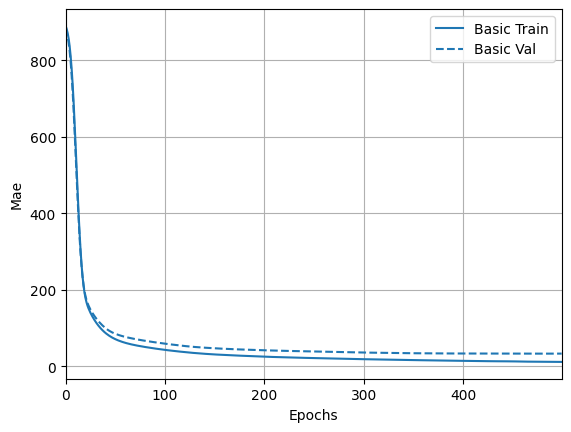

In [49]:
plotter = tfdocs.plots.HistoryPlotter(smoothing_std=2)

# La métrica que se tomará es el MAE
plotter.plot({'Basic': history}, metric = "mae")

In [50]:
model = build_model()

# El parámetro "patience" es la cantidad de épocas para revisar la mejora
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# 
early_history = model.fit(norma_data_train, train_labels, 
                    epochs=500, validation_split = 0.2, verbose=0, 
                    callbacks=[early_stop, tfdocs.modeling.EpochDots()])


Epoch: 0, loss:906142.6875,  mae:909.4896,  mse:906142.6875,  val_loss:888236.5000,  val_mae:908.0197,  val_mse:888236.5000,  
....................................................................................................
Epoch: 100, loss:3258.0220,  mae:45.0804,  mse:3258.0220,  val_loss:5060.6143,  val_mae:55.4254,  val_mse:5060.6143,  
....................................................................................................
Epoch: 200, loss:1085.2092,  mae:25.7943,  mse:1085.2092,  val_loss:2649.2551,  val_mae:39.8154,  val_mse:2649.2551,  
....................................................................................................
Epoch: 300, loss:499.9208,  mae:17.0676,  mse:499.9208,  val_loss:1862.9243,  val_mae:34.2384,  val_mse:1862.9243,  
....................................................................................................
Epoch: 400, loss:267.2466,  mae:12.0926,  mse:267.2466,  val_loss:1589.9209,  val_mae:31.7698,  val_mse:1589.9209

(100.0, 1000.0)

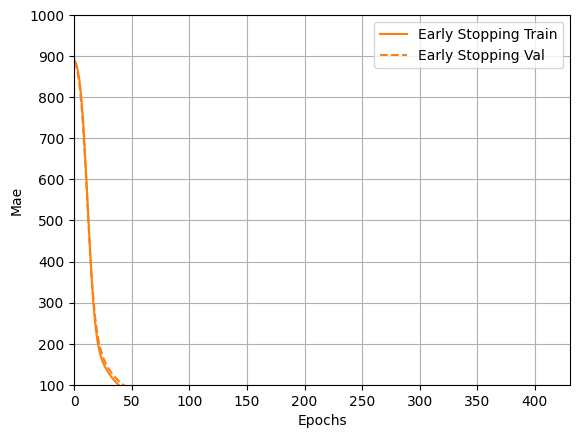

In [51]:
plotter.plot({'Early Stopping': early_history}, metric = "mae")
plt.ylim([100, 1000])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


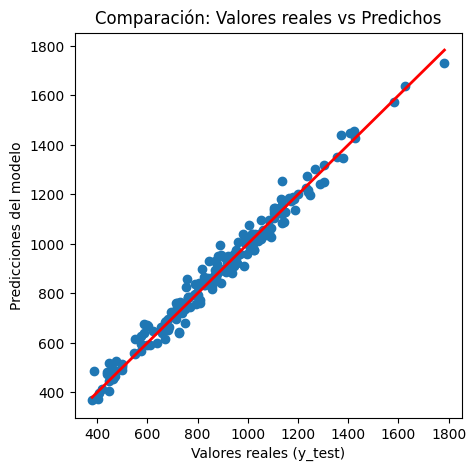

In [52]:
# Realizar predicciones con el conjunto de prueba
predicciones = model.predict(norma_data_test).flatten()

plt.figure(figsize=(5,5))
plt.scatter(test_labels, predicciones)
plt.xlabel('Valores reales (y_test)')
plt.ylabel('Predicciones del modelo')
plt.title('Comparación: Valores reales vs Predichos')
plt.plot([test_labels.min(), test_labels.max()],
         [test_labels.min(), test_labels.max()],
         color='red', lw=2)  # línea ideal y=x
plt.show()

In [53]:
# Tomar las primeras 5 filas del conjunto de prueba normalizado
ejemplo_datos = norma_data_test[:5]
ejemplo_etiquetas_reales = test_labels[:5]

# Generar la predicción
predicciones = model.predict(ejemplo_datos)

# Mostrar los resultados comparados con los valores reales
for i in range(len(predicciones)):
    print(f"Predicción: {predicciones[i][0]:.2f} cal | Real: {ejemplo_etiquetas_reales.iloc[i]} cal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicción: 762.84 cal | Real: 808.0 cal
Predicción: 869.07 cal | Real: 865.0 cal
Predicción: 1015.06 cal | Real: 1030.0 cal
Predicción: 726.24 cal | Real: 721.0 cal
Predicción: 1105.49 cal | Real: 1104.0 cal
